In [3]:
import pandas as pd

df = pd.read_csv("data/Toronto Island Ferry Tickets.csv")

In [4]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   _id               261538 non-null  int64
 1   Timestamp         261538 non-null  str  
 2   Redemption Count  261538 non-null  int64
 3   Sales Count       261538 non-null  int64
dtypes: int64(3), str(1)
memory usage: 8.0 MB


In [6]:
df.shape

(261538, 4)

In [7]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   _id               261538 non-null  int64         
 1   Timestamp         261538 non-null  datetime64[us]
 2   Redemption Count  261538 non-null  int64         
 3   Sales Count       261538 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 8.0 MB


In [10]:
df = df.sort_values("Timestamp")

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour
df["Minute"] = df["Timestamp"].dt.minute
df["Day_of_Week"] = df["Timestamp"].dt.day_name()

df.head()

,_id,Timestamp,Redemption Count,Sales Count,Year,Month,Day,Hour,Minute,Day_of_Week
261537,261538,2015-05-01 13:30:00,0,1,2015,5,1,13,30,Friday
261536,261537,2015-05-01 15:15:00,0,2,2015,5,1,15,15,Friday
261535,261536,2015-05-01 15:45:00,0,1,2015,5,1,15,45,Friday
261534,261535,2015-05-01 16:00:00,1,0,2015,5,1,16,0,Friday
261533,261534,2015-05-04 16:00:00,0,2,2015,5,4,16,0,Monday


Matplotlib is building the font cache; this may take a moment.


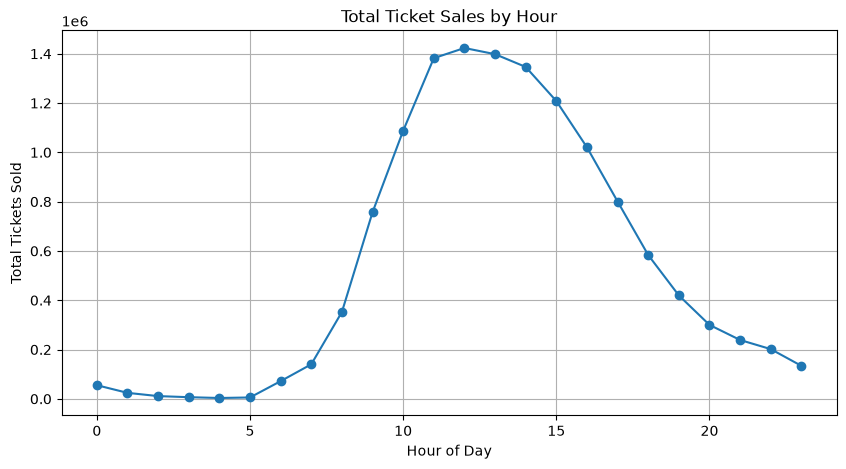

In [13]:
import matplotlib.pyplot as plt

hourly_sales = df.groupby("Hour")["Sales Count"].sum()

plt.figure(figsize=(10,5))
plt.plot(hourly_sales.index, hourly_sales.values, marker="o")
plt.title("Total Ticket Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Tickets Sold")
plt.grid(True)

plt.show()

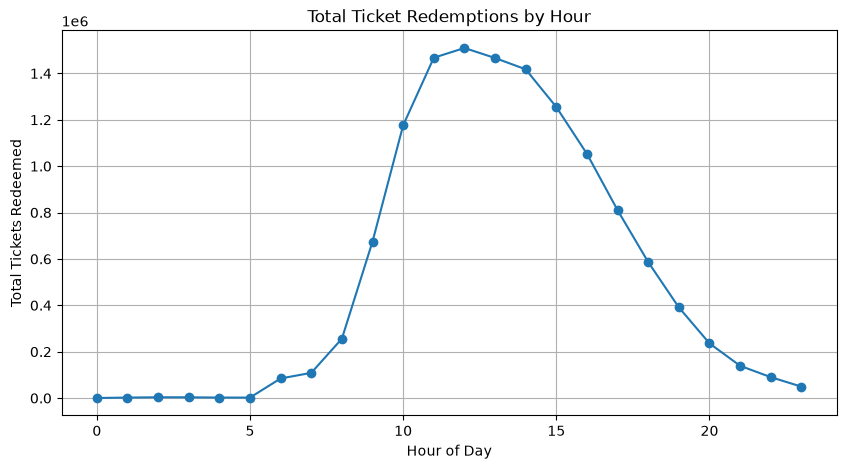

In [14]:
hourly_redemption = df.groupby("Hour")["Redemption Count"].sum()

plt.figure(figsize=(10,5))
plt.plot(hourly_redemption.index, hourly_redemption.values, marker="o")
plt.title("Total Ticket Redemptions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Tickets Redeemed")
plt.grid(True)

plt.show()

# Real-Time Ferry Ticket Sales & Redemption Analytics for Toronto Island Park

## Machine Learning Internship Project

**Prepared by:** Aditya Kumar Pandey

**Organization:** Unified Mentor

**Domain:** Machine Learning

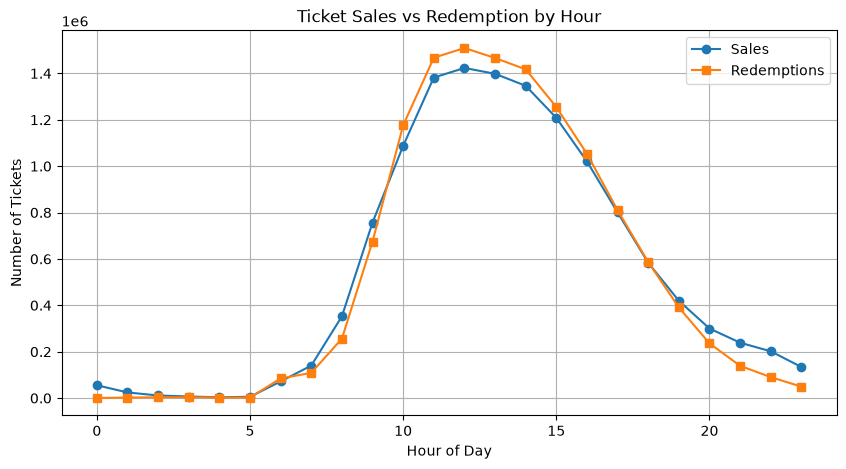

In [15]:
hourly_data = df.groupby("Hour")[["Sales Count", "Redemption Count"]].sum()

plt.figure(figsize=(10,5))

plt.plot(hourly_data.index, hourly_data["Sales Count"], marker="o", label="Sales")
plt.plot(hourly_data.index, hourly_data["Redemption Count"], marker="s", label="Redemptions")

plt.title("Ticket Sales vs Redemption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tickets")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
total_sales = df["Sales Count"].sum()
total_redemptions = df["Redemption Count"].sum()

print("Total Tickets Sold:", total_sales)
print("Total Tickets Redeemed:", total_redemptions)
print("Net Passenger Movement:", total_sales - total_redemptions)

Total Tickets Sold: 12972051
Total Tickets Redeemed: 12785293
Net Passenger Movement: 186758


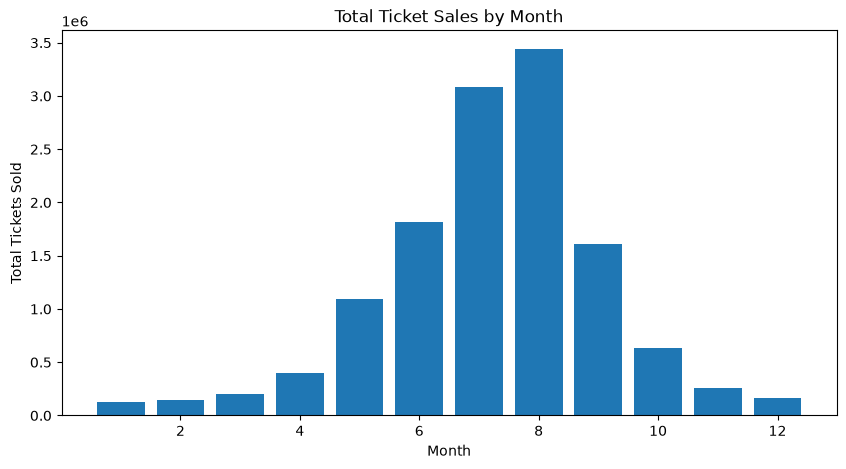

In [17]:
monthly_sales = df.groupby("Month")["Sales Count"].sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Total Ticket Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Tickets Sold")

plt.show()

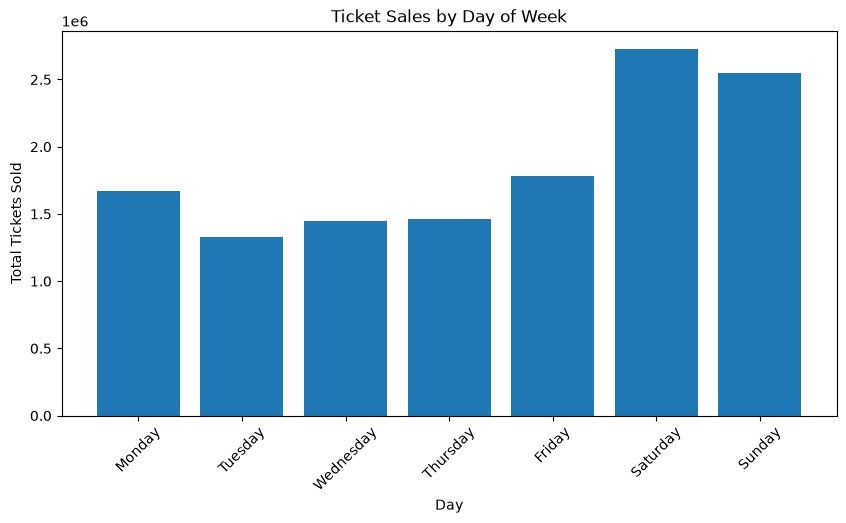

In [18]:
day_sales = df.groupby("Day_of_Week")["Sales Count"].sum()

days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_sales = day_sales.reindex(days)

plt.figure(figsize=(10,5))
plt.bar(day_sales.index, day_sales.values)

plt.title("Ticket Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Tickets Sold")
plt.xticks(rotation=45)

plt.show()

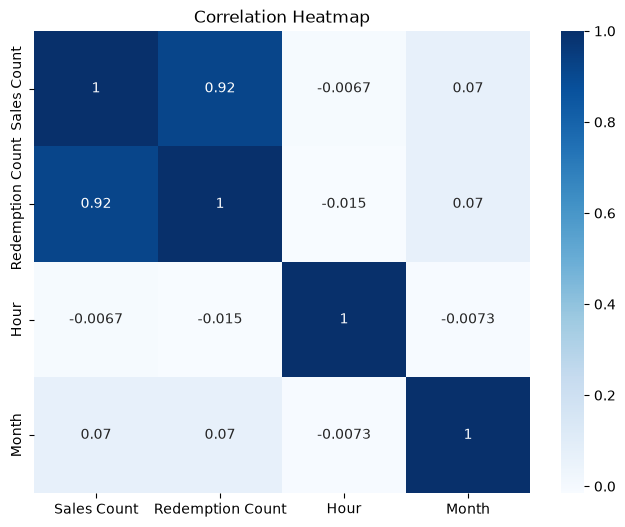

In [19]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales Count","Redemption Count","Hour","Month"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

## 6. Machine Learning

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()

df["Day_of_Week"] = le.fit_transform(df["Day_of_Week"])

In [24]:
X = df[["Year", "Month", "Day", "Hour", "Minute", "Day_of_Week"]]

y = df["Sales Count"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0.35, 2.13,-0.01,-0.11, 0.01,-2.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Year','Month','Day','Hour','Minute','Day_of_Week']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,761.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Day_of_Week"] = le.fit_transform(df["Day_of_Week"])

In [28]:
X = df[["Year", "Month", "Day", "Hour", "Minute", "Day_of_Week"]]

y = df["Sales Count"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0.35, 2.13,-0.01,-0.11, 0.01,-2.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Year','Month','Day','Hour','Minute','Day_of_Week']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,761.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [31]:
y_pred = lr_model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
-------------------------
MAE : 56.86687513467246
MSE : 10336.222579820596
RMSE: 101.66721487195662
R2 Score: 0.007843267414698762


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [34]:
rf_pred = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Random Forest Results
---------------------
MAE : 17.34562284927736
MSE : 4133.002025801025
RMSE: 64.28842839734865
R2 Score: 0.6032800421990963


## 7. Save the Trained Model

In [36]:
import joblib

joblib.dump(rf_model, "ferry_ticket_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [37]:
joblib.dump(le, "label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [39]:
print(le.classes_)

[0 1 2 3 4 5 6]
